In [3]:
import numpy as np
import torch
import os
import sys
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from model_PCA_correlation import AttentionModel_PCA
from dcascore import *
from utils import read_fasta_alignment, remove_duplicate_sequences, add_PCA_coords

# back to original path (in PLM)
sys.path.pop(0)  # Removes the parent_dir from sys.path
from model import AttentionModel

from plm_gen_methods import generate_plm_n_save, generate_coords_n_save, generate_plm_vect_n_save
from seq_utils import read_tensor_from_txt, set_seed, letters_to_nums, modify_seq, find_target_seq

from gen_utils import generate_random, load_train_seqs, load_gen_seqs


In [2]:
N_seqs=15
betas = [1, 0.1, 10]
betas_PCA = [1, 0.1, 10]
target_coords_list = [(24, 20)] #, (27,5), (8,8)]
#generate_random(betas, betas_PCA, N_seqs, target_coords_list, model=3)

In [10]:
sys.path.insert(0, parent_dir)
from model_PCA_cond import ModelPCAcondJ
from dcascore import *
from utils import read_fasta_alignment, remove_duplicate_sequences, add_PCA_coords
def load_condJ_tensor():
    """
    Load Q, K, V matrices from jdoms (after training) and compute Jtens.
    """
    set_seed()
    H = 64
    d= 10
    N = 174
    Nbins=35
    n_epochs = 500
    nb_PCA_comp=2
    loss_type = 'without_J'
    family = 'jdoms' #'jdoms_bacteria_train2'
    cwd = parent_dir
    Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCAcond_J_Nbins35/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
    K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCAcond_J_Nbins35/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
    V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCAcond_J_Nbins35/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
    print("Loaded Q, K, V tensors from PCA_cond model at path: ", cwd +f"/results/{H}_{d}_{family}_{loss_type}_{n_epochs}_PCAcond_J_Nbins35/")
    print(Q_1.shape, K_1.shape, V_1.shape)
    H,d,N=Q_1.shape
    q=V_1.shape[1]
    model=ModelPCAcondJ(H,d,N,q,Nbins,Q=Q_1,V=V_1,K=K_1)
    torch.sum(model.Q-Q_1)
    device = Q_1.device
    L = Q_1.shape[-1]
    W=attention_heads_from_model(model,Q_1,K_1,V_1)
    print(W.shape)

    i_indices = torch.arange(L, device=device).unsqueeze(1)
    j_indices = torch.arange(L, device=device).unsqueeze(0)
    mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
    # Extend mask to cover PCA positions (keep last Ncomp columns unmasked)
    N = Q_1.shape[2]  # M is the number of columns in Q, K, V
    M = K_1.shape[2]  # M is the number of columns in Q, K, V
    print(f"Mask shape: {mask.shape}, N: {N}, M: {M}")
    if M > N:
    # (1, N, M-N) so it matches mask's batch and N dims
        ones_for_pca = torch.ones(1, N, M - N, device=device)
    # concatenate along last dimension -> (1, N, M)
        mask_extended = torch.cat([mask, ones_for_pca], dim=2)
    else:
        mask_extended = mask

    W = W * mask_extended

    # Compute Jtens
    Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
    q = Jtens.shape[0]
    N = Jtens.shape[2]
    print(q)
    print(N)
    print(Jtens.shape)
    return Jtens

In [11]:
Jtens = load_condJ_tensor()

Loaded Q, K, V tensors from PCA_cond model at path:  /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/results/64_10_jdoms_without_J_500_PCAcond_J_Nbins35/
torch.Size([64, 10, 63]) torch.Size([64, 10, 65]) torch.Size([64, 34, 35])
torch.Size([64, 63, 65])
Mask shape: torch.Size([1, 63, 63]), N: 63, M: 65
34
63
torch.Size([34, 35, 63, 65])


In [26]:
save_dir = 'Jcond_method'
Nbins=35
Nseqs=2000
b = 1.2
b_PCAs = [13]
#target = (14, 12)  # Example target coordinates
target = (27, 5)  # Example target coordinates
init_sequence = 2000
for b_PCA in b_PCAs:
    print(f"Generating sequences with beta: {b}, beta_PCA: {b_PCA}, target: {target}")
    # Generate sequences with PCA coordinates
    if b_PCA == 0:
        b_PCA = None  # No PCA component if b_PCA is 0
    else:
        b_PCA = b_PCA  # Use the specified PCA component
        save_name = f'Nbins{Nbins}_gen_{init_sequence}_{Nseqs}_{b}_{b_PCA}_{target[0]}_{target[1]}'
        target_coords = np.array(target)
        #generated_sequences = generate_plm_vect_n_save(save_dir, save_name, J=Jtens, n_iter=Nseqs, init_sequence=init_sequence,beta=b,nb_PCA_comp=2,PCA_comp_list=target_coords,J_PCA=None,beta_PCA=b_PCA)

Generating sequences with beta: 1.2, beta_PCA: 13, target: (27, 5)


Plotting PCA results for beta_PCA: 13
Loaded 14502 training sequences from /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta
Loaded 2000 generated sequences from Jcond_methodPCA_comp/Nbins35_gen_2000_2000_1.2_13_27_5PCA_comp
Shape of loaded sequences: (2000, 63)


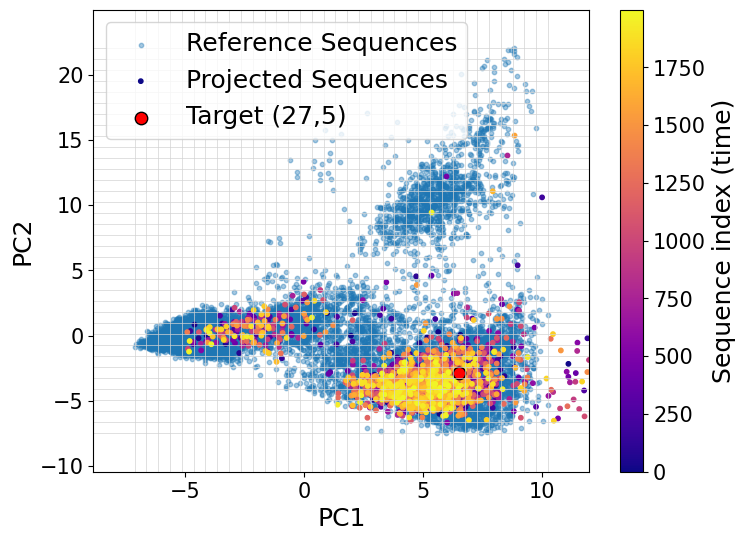

In [27]:
from gen_utils import plot_pca_results
save_dir = 'Jcond_methodPCA_comp'
#target = (14, 12)  # Example target coordinates
#target_coords = np.array(target)

for b_PCA in b_PCAs:
    print(f"Plotting PCA results for beta_PCA: {b_PCA}")
    if b_PCA == 0:
        b_PCA = None  # No PCA component if b_PCA is 0
    else:
        b_PCA = b_PCA  # Use the specified PCA component
        save_name = f'Nbins{Nbins}_gen_{init_sequence}_{Nseqs}_{b}_{b_PCA}_{target[0]}_{target[1]}PCA_comp'
        #save_name = f'gen_{init_sequence}_{Nseqs}_{b}_{b_PCA}_{target[0]}_{target[1]}PCA_comp'

        plot_pca_results(file_dir=save_dir, file_name=save_name, target_coords=target_coords, Nbins=Nbins, mac=True)

In [4]:
#sys.path.insert(0, parent_dir)
#from model_PCA_cond import ModelPCACond
#from dcascore import *
#from utils import read_fasta_alignment, remove_duplicate_sequences, add_PCA_coords
#def load_J_tensor():
#    """
#    Load Q, K, V matrices from jdoms (after training) and compute Jtens.
#    """
#    set_seed()
#    H = 64
#    d= 10
#    N = 174
#    Nbins=20
#    n_epochs = 500
#    nb_PCA_comp=2
#    loss_type = 'without_J'
#    family = 'jdoms' #'jdoms_bacteria_train2'
#    cwd = parent_dir
#        Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCA_cond/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
#        K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCA_cond/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
#        V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCA_cond/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
#        G_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCA_cond/G_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
#
#    print("Loaded Q, K, V tensors from PCA_cond model at path: ", cwd +f"/results/{H}_{d}_{family}_{loss_type}_{n_epochs}_PCAcond_J/")
#    print(Q_1.shape, K_1.shape, V_1.shape, G_1.shape)
#    H,d,N=Q_1.shape
#    q=V_1.shape[1]
#    model=ModelPCACond(H,d,N,q,Nbins,Q=Q_1,V=V_1,K=K_1,G=G_1)
#    torch.sum(model.Q-Q_1)
#    device = Q_1.device
#    L = Q_1.shape[-1]
#    W=attention_heads_from_model(model,Q_1,K_1,V_1)
#    print(W.shape)
#
#    i_indices = torch.arange(L, device=device).unsqueeze(1)
#    j_indices = torch.arange(L, device=device).unsqueeze(0)
#    mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
#    W = W * mask
#
#    # Compute Jtens
#    Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
#    q = Jtens.shape[0]
#    N = Jtens.shape[2]
#    print(q)
#    print(N)
#    print(Jtens.shape)
#    return Jtens

In [5]:
Jtens = load_condJ_tensor()

Loaded Q, K, V tensors from PCA_cond model at path:  /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/results/64_10_jdoms_without_J_500_PCAcond_J/
torch.Size([64, 10, 63]) torch.Size([64, 10, 65]) torch.Size([64, 21, 21])
torch.Size([64, 63, 65])


RuntimeError: The size of tensor a (65) must match the size of tensor b (63) at non-singleton dimension 2

In [ ]:
from plm_gen_methods import generate_plm_cond_n_save
save_dir = "gen_plm_cond"
N_seqs = 10000
target = np.array([14, 12])  # Example target coordinates
target = np.array([15, 3])
#target = np.array([5, 5])
beta = 1
beta_PCA = 1
save_name = f"{N_seqs}_b{beta}_bPCA{beta_PCA}_{target[0]}_{target[1]}"

generate_plm_cond_n_save(save_dir, save_name, Jtens, G, N_seqs=N_seqs, init_sequence=None,beta=beta,nb_PCA_comp=2,PCA_comp_list=target,beta_PCA=beta_PCA)


100%|██████████| 10000/10000 [03:40<00:00, 45.44it/s]


Generated sequences (letters): ['HYRMI-HWMM-EID-CNGC-ANNTLLRRWNYDFWH-KHVEQVK-CYRHNIRDQTEVIECGLEV', 'HYRMI-HWMW-EID-CNGC-ANNTLLRRWNYDFWH-KHVEQVK-CYRHNIRDQTEVIECGLEV', 'HYRMI-HWMW-EIS-CNGC-ANNTLLRRWNYDFWH-KHVEQVK-CYRHNIRDQTEVIECGLEV', 'HYRMI-HWMW-EISCCNGC-ANNTLLRRWNYDFWH-KHVEQVK-CYRHNIRDQTEVIECGLEV', 'HYRMI-HWMW-EISCCNGC-ANMTLLRRWNYDFWH-KHVEQVK-CYRHNIRDQTEVIECGLEV']
Generated sequences saved to gen_plm_cond


Loaded 14502 training sequences from /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta
Loaded 10000 generated sequences from /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/Sequences/gen_plm_cond/10000_b1_bPCA1_15_3
Shape of loaded sequences: (10000, 63)


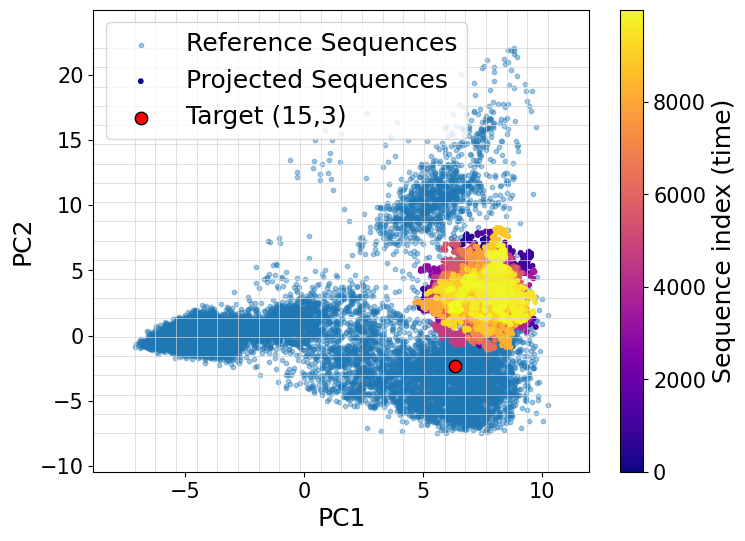

In [ ]:
cwd = os.getcwd()
file_dir = os.path.join(cwd, "Sequences","gen_plm_cond")
# name from target array
target_name = f"{target[0]}_{target[1]}"  # Convert target coordinates to string
name = f"{N_seqs}_b{beta}_bPCA{beta_PCA}_{target_name}"  # Example file name
train_sequences = load_train_seqs(mac=True)
gen_sequences = load_gen_seqs(file_dir, name, mac=True)
# take one every 100
plot_projected_pca_time(sequences_reference=train_sequences, sequences_to_project=gen_sequences, title="PCA Projection: Train vs Generated", Nbins=20, target_coords=target)
